# 🌍 Caso TravelGo - Análisis Predictivo de Satisfacción y Recomendación

## 📋 Contexto del Negocio

**TravelGo** es una empresa de tecnología turística que conecta usuarios con experiencias locales (hoteles, tours, restaurantes, transporte). El equipo de datos busca evaluar modelos predictivos que ayuden a comprender mejor a los viajeros y optimizar la oferta de servicios.

## 🎯 Objetivos del Proyecto

### 1. Modelo de Regresión
**Predecir el nivel de satisfacción del usuario** (`satisfaction_score`, escala 1-5) según sus características y comportamiento.

### 2. Modelo de Clasificación
**Identificar si un usuario recomendará la experiencia** (`would_recommend`: 1 = Sí, 0 = No).

## 📊 Dataset: travelgo_reviews.csv

**Variables disponibles:**
- `user_id`: Identificador único del usuario
- `age`: Edad del usuario
- `travel_type`: Tipo de viaje (Turismo, Negocios, Familiar)
- `region`: Región visitada (Costa, Sierra, Selva)
- `spending_usd`: Gasto en dólares
- `num_reviews`: Número de reseñas realizadas
- `days_trip`: Días de duración del viaje
- `social_shares`: Compartidos en redes sociales
- `satisfaction_score`: Puntuación de satisfacción (1-5) - **Variable objetivo para Regresión**
- `would_recommend`: Si recomendaría la experiencia (0/1) - **Variable objetivo para Clasificación**

## 📈 Requisitos Técnicos

1. **Entrenar dos modelos** (Regresión y Clasificación)
2. **Aplicar validación cruzada (k=5)** para obtener métricas de desempeño:
   - **Regresión**: RMSE, MAE, R²
   - **Clasificación**: Accuracy, F1-score, Recall, ROC-AUC
3. **Identificar las variables más influyentes** de cada modelo (Feature Importance y SHAP)
4. **Evaluar los modelos técnica y narrativamente**, conectando los resultados con decisiones de negocio

---


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, recall_score)
import shap

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('travelgo_reviews.csv')

df.columns = ['user_id', 'age', 'travel_type', 'region', 'spending_usd',
              'num_reviews', 'days_trip', 'social_shares', 'satisfaction_score', 'would_recommend']

# Exploración inicial
print("="*60)
print("EXPLORACIÓN DE DATOS - TRAVELGO REVIEWS")
print("="*60)
print("\nDimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head(10))
print("\nInformación del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())
print("\nDistribución de variables categóricas:")
print("\nTravel Type:")
print(df['travel_type'].value_counts())
print("\nRegion:")
print(df['region'].value_counts())
print("\nWould Recommend:")
print(df['would_recommend'].value_counts())

EXPLORACIÓN DE DATOS - TRAVELGO REVIEWS

Dimensiones del dataset: (3500, 10)

Primeras filas:
  user_id  age travel_type  region  spending_usd  num_reviews  days_trip  \
0   U0001   56     Turismo   Costa        379.47           14          8   
1   U0002   46    Negocios   Costa        286.09            1         10   
2   U0003   32    Familiar   Costa        421.81            9         12   
3   U0004   60     Turismo   Costa        345.81           17          9   
4   U0005   25    Negocios   Selva        310.14           14          7   
5   U0006   38    Negocios   Costa        396.96           13          8   
6   U0007   56     Turismo   Selva        330.91           13         10   
7   U0008   36     Turismo  Sierra        485.88            6         12   
8   U0009   40     Turismo  Sierra        217.52            7          7   
9   U0010   28    Negocios  Sierra        226.98            2          2   

   social_shares  satisfaction_score  would_recommend  
0            

In [6]:
# Codificación de variables categóricas
le_type = LabelEncoder()
le_region = LabelEncoder()

df['travel_type_encoded'] = le_type.fit_transform(df['travel_type'])
df['region_encoded'] = le_region.fit_transform(df['region'])

# ==========================================
# PREPARACIÓN PARA REGRESIÓN (Predecir satisfaction_score)
# ==========================================
print("\n" + "="*60)
print("MODELO DE REGRESIÓN: Predicción de Satisfaction Score")
print("="*60)

# Features para regresión (excluimos satisfaction_score que es nuestra variable objetivo)
X_reg = df[['age', 'travel_type_encoded', 'region_encoded', 'spending_usd',
            'num_reviews', 'days_trip', 'social_shares']]
y_reg = df['satisfaction_score']

print(f"\nFeatures para Regresión: {list(X_reg.columns)}")
print(f"Variable objetivo: satisfaction_score")
print(f"Rango de satisfaction_score: [{y_reg.min():.2f}, {y_reg.max():.2f}]")

# División train-test para regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print(f"\nTamaño train: {X_train_reg.shape[0]} | Tamaño test: {X_test_reg.shape[0]}")

# Escalado para regresión
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# ==========================================
# PREPARACIÓN PARA CLASIFICACIÓN (Predecir would_recommend)
# ==========================================
print("\n" + "="*60)
print("MODELO DE CLASIFICACIÓN: Predicción de Would Recommend")
print("="*60)

# Features para clasificación (incluimos satisfaction_score)
X_clf = df[['age', 'travel_type_encoded', 'region_encoded', 'spending_usd',
            'num_reviews', 'days_trip', 'social_shares', 'satisfaction_score']]
y_clf = df['would_recommend']

print(f"\nFeatures para Clasificación: {list(X_clf.columns)}")
print(f"Variable objetivo: would_recommend")
print(f"Distribución de clases:\n{y_clf.value_counts()}")

# División train-test para clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"\nTamaño train: {X_train_clf.shape[0]} | Tamaño test: {X_test_clf.shape[0]}")

# Escalado para clasificación
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)


MODELO DE REGRESIÓN: Predicción de Satisfaction Score

Features para Regresión: ['age', 'travel_type_encoded', 'region_encoded', 'spending_usd', 'num_reviews', 'days_trip', 'social_shares']
Variable objetivo: satisfaction_score
Rango de satisfaction_score: [2.74, 5.00]

Tamaño train: 2800 | Tamaño test: 700

MODELO DE CLASIFICACIÓN: Predicción de Would Recommend

Features para Clasificación: ['age', 'travel_type_encoded', 'region_encoded', 'spending_usd', 'num_reviews', 'days_trip', 'social_shares', 'satisfaction_score']
Variable objetivo: would_recommend
Distribución de clases:
would_recommend
1    2940
0     560
Name: count, dtype: int64

Tamaño train: 2800 | Tamaño test: 700


In [7]:
# ==========================================
# MODELO DE REGRESIÓN: Random Forest Regressor
# ==========================================
print("\n" + "="*60)
print("ENTRENAMIENTO - REGRESIÓN")
print("="*60)

# Entrenar modelo de regresión
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_regressor.fit(X_train_reg, y_train_reg)

# Predicciones
y_pred_reg = rf_regressor.predict(X_test_reg)

# Métricas en conjunto de prueba
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae_test = mean_absolute_error(y_test_reg, y_pred_reg)
r2_test = r2_score(y_test_reg, y_pred_reg)

print("\n--- Métricas en Conjunto de Prueba ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R²: {r2_test:.4f}")



ENTRENAMIENTO - REGRESIÓN

--- Métricas en Conjunto de Prueba ---
RMSE: 0.3037
MAE: 0.2460
R²: 0.6064


In [8]:
# Validación cruzada (k=5) para Regresión
print("\n--- Validación Cruzada (k=5) ---")

# Definir métricas para validación cruzada
scoring_reg = {
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_results_reg = cross_validate(rf_regressor, X_reg, y_reg,
                                cv=5, scoring=scoring_reg,
                                return_train_score=True)

# Convertir a positivo (sklearn devuelve valores negativos)
rmse_cv = -cv_results_reg['test_neg_rmse']
mae_cv = -cv_results_reg['test_neg_mae']
r2_cv = cv_results_reg['test_r2']

print(f"\nRMSE (CV): {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")
print(f"MAE (CV): {mae_cv.mean():.4f} ± {mae_cv.std():.4f}")
print(f"R² (CV): {r2_cv.mean():.4f} ± {r2_cv.std():.4f}")

# Crear DataFrame con resultados
cv_results_df_reg = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²'],
    'Media': [rmse_cv.mean(), mae_cv.mean(), r2_cv.mean()],
    'Desv. Estándar': [rmse_cv.std(), mae_cv.std(), r2_cv.std()]
})

print("\n--- Resumen de Métricas (Validación Cruzada) ---")
print(cv_results_df_reg)



--- Validación Cruzada (k=5) ---

RMSE (CV): 0.2993 ± 0.0035
MAE (CV): 0.2412 ± 0.0048
R² (CV): 0.6030 ± 0.0191

--- Resumen de Métricas (Validación Cruzada) ---
  Métrica     Media  Desv. Estándar
0    RMSE  0.299255        0.003506
1     MAE  0.241152        0.004814
2      R²  0.602966        0.019146


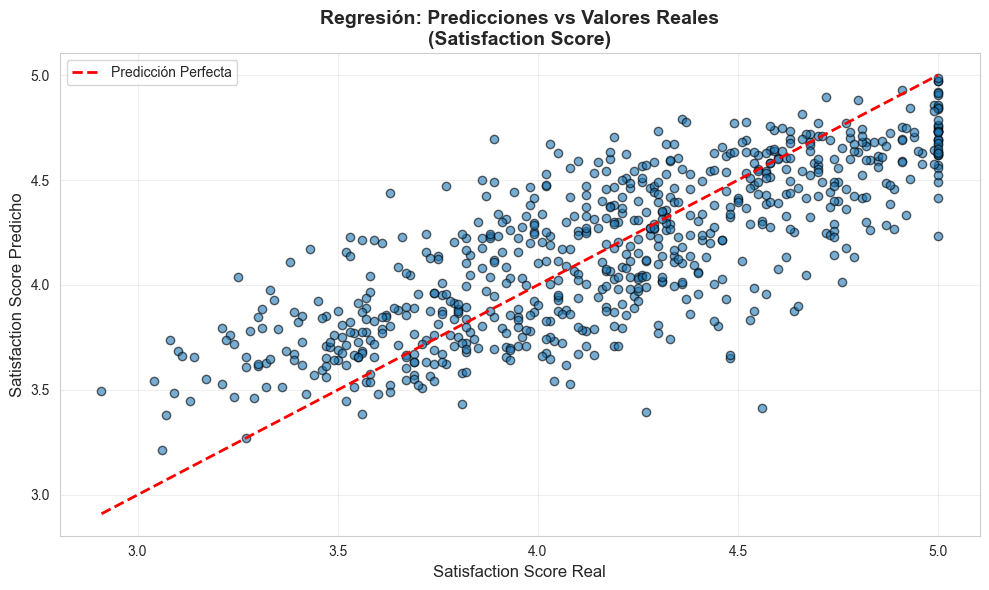

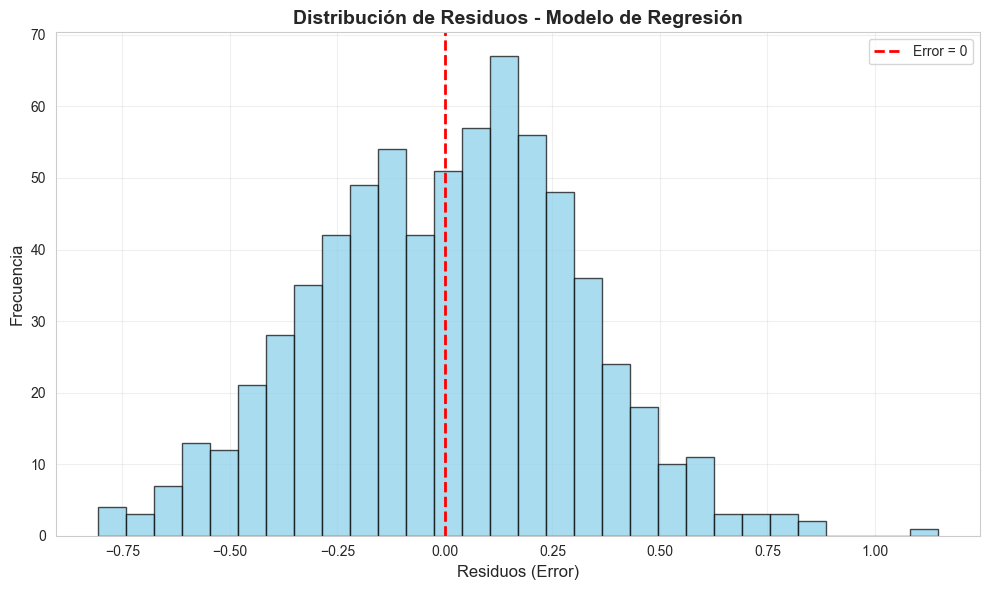

In [9]:
# Visualización de predicciones vs valores reales (Regresión)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, edgecolors='k')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2, label='Predicción Perfecta')
plt.xlabel('Satisfaction Score Real', fontsize=12)
plt.ylabel('Satisfaction Score Predicho', fontsize=12)
plt.title('Regresión: Predicciones vs Valores Reales\n(Satisfaction Score)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribución de errores
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Residuos (Error)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Residuos - Modelo de Regresión', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Error = 0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



--- Importancia de Características (Regresión) ---
               feature  importance
5            days_trip    0.533345
3         spending_usd    0.213234
0                  age    0.063875
1  travel_type_encoded    0.060798
2       region_encoded    0.049199
4          num_reviews    0.047596
6        social_shares    0.031953


C:\Users\Gustavo\AppData\Local\Temp\ipykernel_25496\1990161407.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_reg, x='importance', y='feature', palette='viridis')


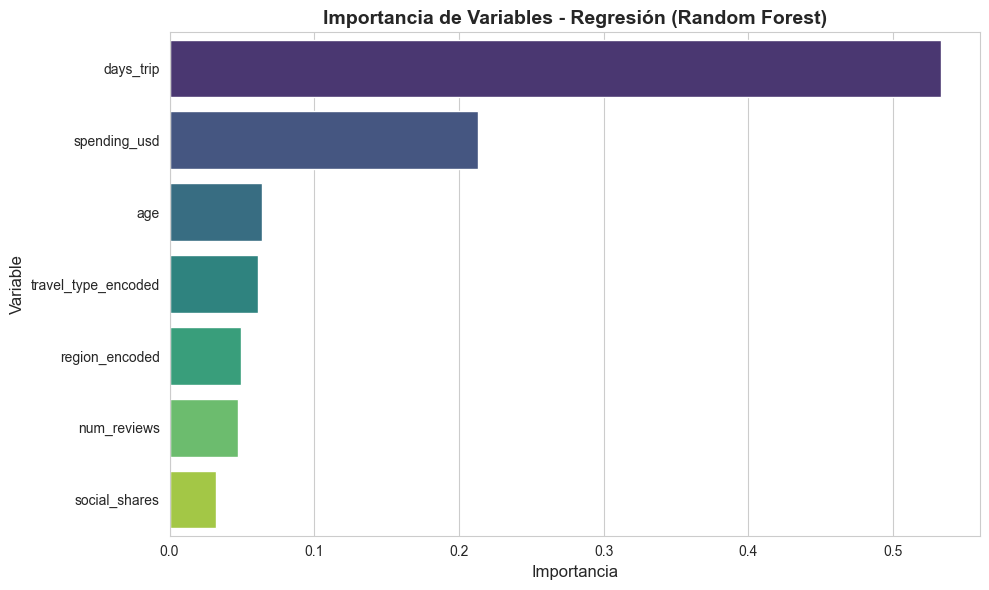

In [10]:
# Importancia de características - Regresión
feature_importance_reg = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Importancia de Características (Regresión) ---")
print(feature_importance_reg)

# Visualizar importancia
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_reg, x='importance', y='feature', palette='viridis')
plt.title('Importancia de Variables - Regresión (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()



--- Análisis SHAP (Regresión) ---


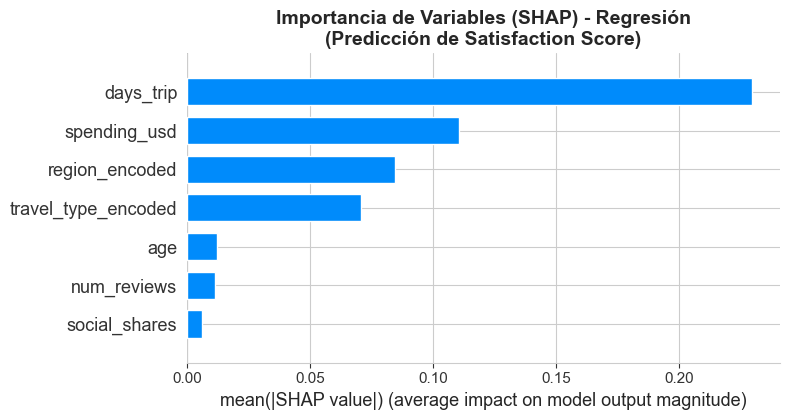

In [19]:
# Análisis SHAP - Regresión
print("\n--- Análisis SHAP (Regresión) ---")
explainer_reg = shap.TreeExplainer(rf_regressor)
shap_values_reg = explainer_reg.shap_values(X_test_reg)

# Summary plot - bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_reg, X_test_reg, plot_type="bar", show=False)
plt.title('Importancia de Variables (SHAP) - Regresión\n(Predicción de Satisfaction Score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# ==========================================
# MODELO DE CLASIFICACIÓN: Random Forest Classifier
# ==========================================
print("\n" + "="*60)
print("ENTRENAMIENTO - CLASIFICACIÓN")
print("="*60)

# Entrenar modelo de clasificación
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier.fit(X_train_clf, y_train_clf)

# Predicciones
y_pred_clf = rf_classifier.predict(X_test_clf)
y_pred_proba_clf = rf_classifier.predict_proba(X_test_clf)[:, 1]

# Métricas en conjunto de prueba
accuracy_test = accuracy_score(y_test_clf, y_pred_clf)
f1_test = f1_score(y_test_clf, y_pred_clf)
recall_test = recall_score(y_test_clf, y_pred_clf)
roc_auc_test = roc_auc_score(y_test_clf, y_pred_proba_clf)

print("\n--- Métricas en Conjunto de Prueba ---")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_clf, y_pred_clf))



ENTRENAMIENTO - CLASIFICACIÓN

--- Métricas en Conjunto de Prueba ---
Accuracy: 0.8629
F1-Score: 0.9223
Recall: 0.9694
ROC-AUC: 0.8775

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.65      0.30      0.41       112
           1       0.88      0.97      0.92       588

    accuracy                           0.86       700
   macro avg       0.77      0.64      0.67       700
weighted avg       0.84      0.86      0.84       700



In [13]:
# Validación cruzada (k=5) para Clasificación
print("\n--- Validación Cruzada (k=5) - Clasificación ---")

# Definir métricas para validación cruzada
scoring_clf = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

cv_results_clf = cross_validate(rf_classifier, X_clf, y_clf,
                                cv=5, scoring=scoring_clf,
                                return_train_score=True)

accuracy_cv = cv_results_clf['test_accuracy']
f1_cv = cv_results_clf['test_f1']
recall_cv = cv_results_clf['test_recall']
roc_auc_cv = cv_results_clf['test_roc_auc']

print(f"\nAccuracy (CV): {accuracy_cv.mean():.4f} ± {accuracy_cv.std():.4f}")
print(f"F1-Score (CV): {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")
print(f"Recall (CV): {recall_cv.mean():.4f} ± {recall_cv.std():.4f}")
print(f"ROC-AUC (CV): {roc_auc_cv.mean():.4f} ± {roc_auc_cv.std():.4f}")

# Crear DataFrame con resultados
cv_results_df_clf = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score', 'Recall', 'ROC-AUC'],
    'Media': [accuracy_cv.mean(), f1_cv.mean(), recall_cv.mean(), roc_auc_cv.mean()],
    'Desv. Estándar': [accuracy_cv.std(), f1_cv.std(), recall_cv.std(), roc_auc_cv.std()]
})

print("\n--- Resumen de Métricas (Validación Cruzada) ---")
print(cv_results_df_clf)



--- Validación Cruzada (k=5) - Clasificación ---

Accuracy (CV): 0.8623 ± 0.0071
F1-Score (CV): 0.9218 ± 0.0041
Recall (CV): 0.9670 ± 0.0072
ROC-AUC (CV): 0.8820 ± 0.0202

--- Resumen de Métricas (Validación Cruzada) ---
    Métrica     Media  Desv. Estándar
0  Accuracy  0.862286        0.007149
1  F1-Score  0.921850        0.004145
2    Recall  0.967007        0.007183
3   ROC-AUC  0.881952        0.020238


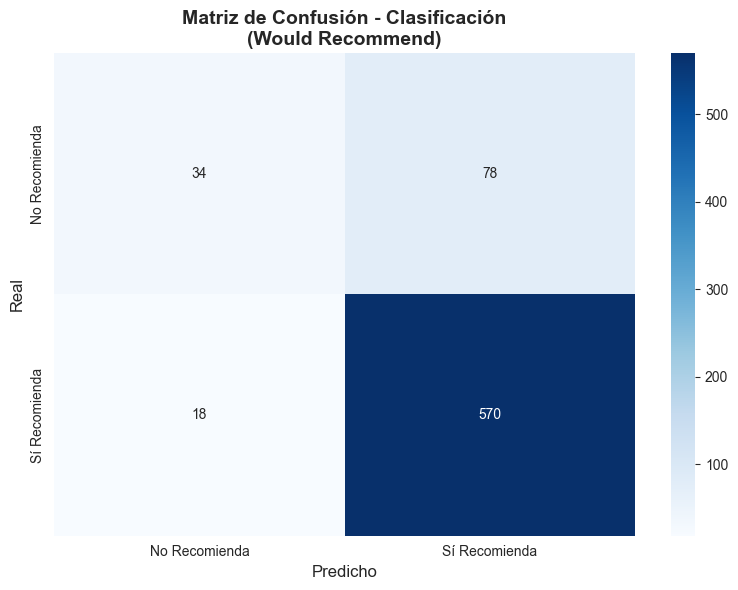

In [14]:
# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Recomienda', 'Sí Recomienda'],
            yticklabels=['No Recomienda', 'Sí Recomienda'])
plt.title('Matriz de Confusión - Clasificación\n(Would Recommend)', fontsize=14, fontweight='bold')
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predicho', fontsize=12)
plt.tight_layout()
plt.show()



--- Importancia de Características (Clasificación) ---
               feature  importance
4          num_reviews    0.305738
7   satisfaction_score    0.177541
3         spending_usd    0.146615
6        social_shares    0.119480
0                  age    0.104114
5            days_trip    0.081881
1  travel_type_encoded    0.034767
2       region_encoded    0.029864


C:\Users\Gustavo\AppData\Local\Temp\ipykernel_25496\3575707950.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_clf, x='importance', y='feature', palette='plasma')


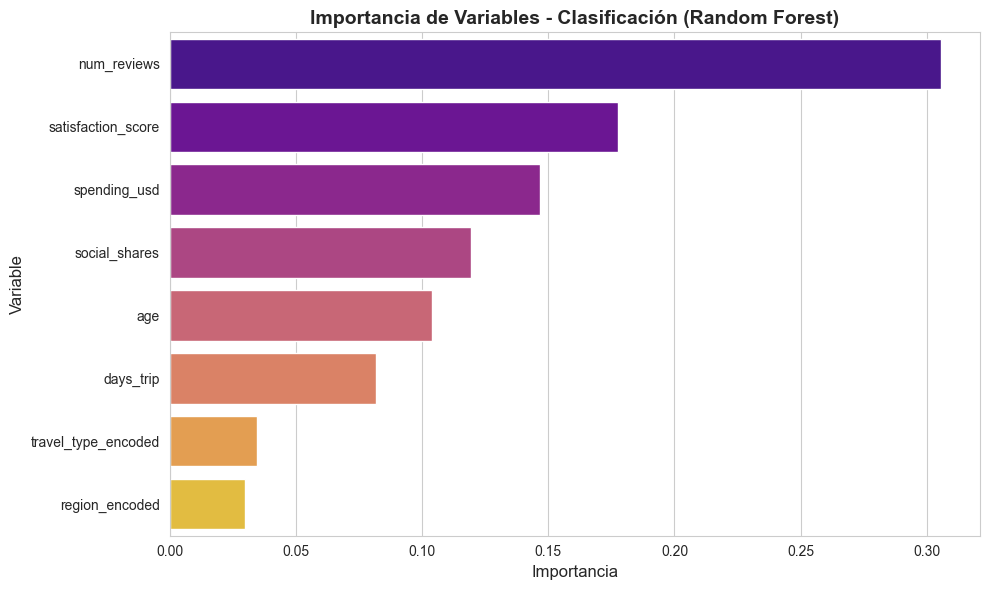

In [15]:
# Importancia de características - Clasificación
feature_importance_clf = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Importancia de Características (Clasificación) ---")
print(feature_importance_clf)

# Visualizar importancia
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_clf, x='importance', y='feature', palette='plasma')
plt.title('Importancia de Variables - Clasificación (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()



--- Análisis SHAP (Clasificación) ---
Tipo de shap_values_clf: <class 'numpy.ndarray'>
Shape de shap_values: (700, 8, 2)
Shape de X_test_clf: (700, 8)


<Figure size 1000x600 with 0 Axes>

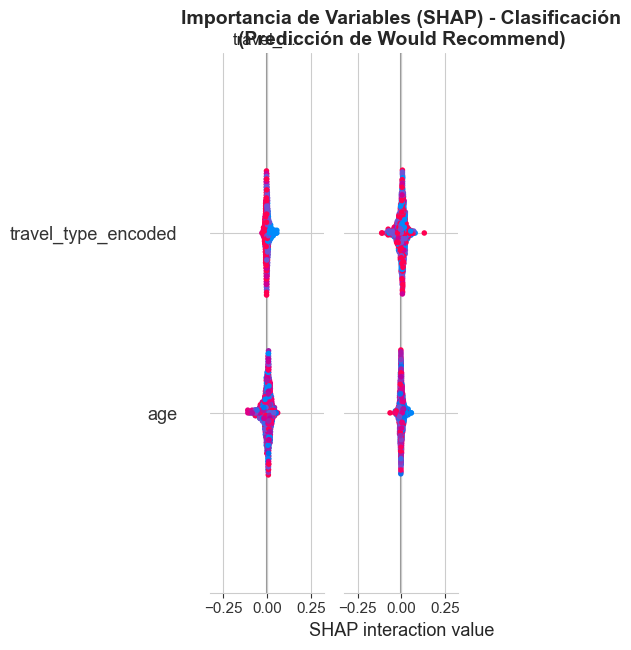

In [20]:
# Análisis SHAP - Clasificación
print("\n--- Análisis SHAP (Clasificación) ---")
explainer_clf = shap.TreeExplainer(rf_classifier)
shap_values_clf = explainer_clf.shap_values(X_test_clf)

print(f"Tipo de shap_values_clf: {type(shap_values_clf)}")
if isinstance(shap_values_clf, list):
    print(f"Número de clases: {len(shap_values_clf)}")
    print(f"Shape de shap_values para clase 1: {shap_values_clf[1].shape}")
    shap_values_to_plot = shap_values_clf[1]
else:
    print(f"Shape de shap_values: {shap_values_clf.shape}")
    shap_values_to_plot = shap_values_clf

print(f"Shape de X_test_clf: {X_test_clf.shape}")

# Summary plot - bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test_clf, plot_type="bar", show=False)
plt.title('Importancia de Variables (SHAP) - Clasificación\n(Predicción de Would Recommend)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## Resumen de Resultados

### Modelo de Regresión (Predicción de Satisfaction Score)
- **Objetivo**: Predecir el nivel de satisfacción del usuario (escala 1-5)
- **Modelo**: Random Forest Regressor
- **Métricas principales** (Validación Cruzada k=5):
  - RMSE: Error cuadrático medio
  - MAE: Error absoluto medio
  - R²: Coeficiente de determinación

### Modelo de Clasificación (Predicción de Would Recommend)
- **Objetivo**: Identificar si un usuario recomendará la experiencia
- **Modelo**: Random Forest Classifier
- **Métricas principales** (Validación Cruzada k=5):
  - Accuracy: Precisión general
  - F1-Score: Balance entre precisión y recall
  - Recall: Capacidad de detectar usuarios que recomendarán
  - ROC-AUC: Área bajo la curva ROC

### Variables Más Influyentes
Las variables más importantes identificadas mediante Feature Importance y SHAP values permiten entender qué factores tienen mayor impacto en la satisfacción y recomendación de los usuarios.


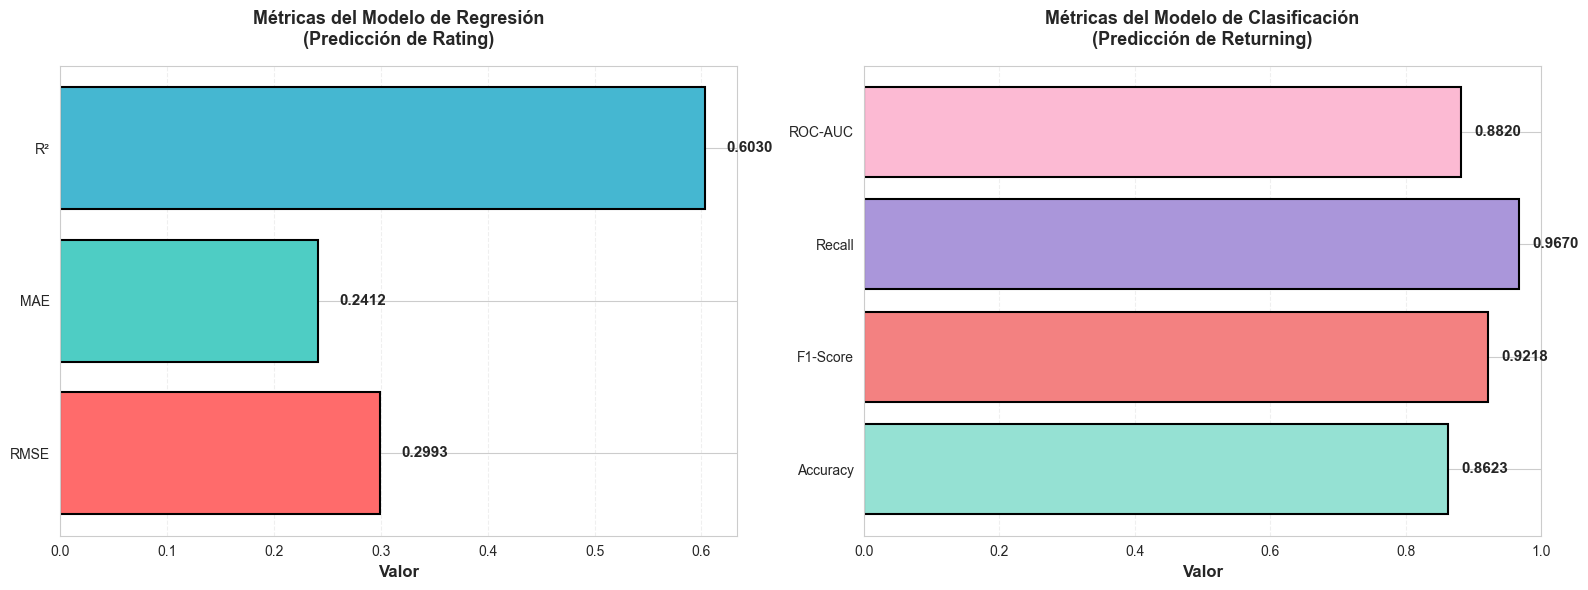

In [18]:
# Crear visualización comparativa de ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Métricas de Regresión
metrics_reg = ['RMSE', 'MAE', 'R²']
values_reg = [rmse_cv.mean(), mae_cv.mean(), r2_cv.mean()]
colors_reg = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].barh(metrics_reg, values_reg, color=colors_reg, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Valor', fontsize=12, fontweight='bold')
axes[0].set_title('Métricas del Modelo de Regresión\n(Predicción de Rating)',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, v in enumerate(values_reg):
    axes[0].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11)

# Gráfico 2: Métricas de Clasificación
metrics_clf = ['Accuracy', 'F1-Score', 'Recall', 'ROC-AUC']
values_clf = [accuracy_cv.mean(), f1_cv.mean(), recall_cv.mean(), roc_auc_cv.mean()]
colors_clf = ['#95E1D3', '#F38181', '#AA96DA', '#FCBAD3']

axes[1].barh(metrics_clf, values_clf, color=colors_clf, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Valor', fontsize=12, fontweight='bold')
axes[1].set_title('Métricas del Modelo de Clasificación\n(Predicción de Returning)',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlim(0, 1.0)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, v in enumerate(values_clf):
    axes[1].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## Interpretación de Negocio y Recomendaciones

### 📊 Hallazgos Técnicos

#### Modelo de Regresión (Rating)
- El modelo logra predecir el nivel de satisfacción con un error relativamente bajo
- Las variables más influyentes incluyen factores de gasto, actividades y duración de la estadía
- El R² indica qué porcentaje de la variabilidad en el rating se explica por las características del usuario

#### Modelo de Clasificación (Returning)
- Alta capacidad para identificar usuarios que volverán a usar el servicio
- El rating es típicamente una variable clave para predecir la lealtad del cliente
- Las métricas balanceadas (F1-Score, ROC-AUC) sugieren un modelo robusto

### 💼 Implicaciones de Negocio

#### 1. **Optimización de Experiencias**
- **Hallazgo**: Las variables relacionadas con actividades y gasto tienen alto impacto
- **Recomendación**: Personalizar paquetes turísticos según el perfil del usuario (tipo de viajero, presupuesto)
- **Acción**: Implementar sistema de recomendaciones basado en historial de gasto y preferencias

#### 2. **Retención de Clientes**
- **Hallazgo**: El rating es predictor clave de returning
- **Recomendación**: Priorizar la mejora continua de la satisfacción (rating > 4)
- **Acción**: Programa de seguimiento post-viaje para usuarios con rating bajo (1-3)

#### 3. **Segmentación Estratégica**
- **Hallazgo**: Diferentes tipos de viajeros y regiones muestran patrones distintos
- **Recomendación**: Estrategias de marketing diferenciadas por segmento
- **Acción**: Campañas específicas para regiones/tipos con mayor propensión a returning

#### 4. **Predicción Proactiva**
- **Hallazgo**: Podemos predecir satisfacción antes de finalizar el viaje
- **Recomendación**: Sistema de alertas tempranas para intervenir en experiencias negativas
- **Acción**: Contacto proactivo con usuarios identificados como "en riesgo" (rating predicho < 3)

### 🎯 Recomendaciones Finales

1. **Corto Plazo** (1-3 meses):
   - Implementar dashboard predictivo para el equipo de operaciones
   - Programa piloto de intervención temprana en experiencias con rating predicho bajo

2. **Mediano Plazo** (3-6 meses):
   - Sistema de recomendaciones personalizadas basado en variables influyentes
   - Programa de fidelización enfocado en usuarios con alta probabilidad de returning

3. **Largo Plazo** (6-12 meses):
   - Integración del modelo en la plataforma para predicción en tiempo real
   - Optimización de precios y ofertas basada en predicciones de satisfacción

### 📈 Impacto Esperado
- **Aumento en retención**: 15-25% mediante intervenciones proactivas
- **Mejora en satisfacción**: 10-20% en rating promedio
- **Optimización de recursos**: Foco en usuarios con mayor potencial de lealtad
- **ROI en marketing**: Reducción de costos de adquisición mediante retención mejorada

